# Implementation of the market gap analysis
## Set up and installation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re



### The dataset is huge (3GB+), so we load only the first 500,000 rows
### and only the columns we actually need — this keeps memory manageable


In [2]:
cols_needed = [
    'product_name',
    'categories_tags',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g',
    'energy_100g',
    'ingredients_text',
    'countries_tags'
]

df = pd.read_csv(
    "en.openfoodfacts.org.products.csv",
    sep='\t',                      # Open Food Facts uses TAB as separator, not comma
    usecols=cols_needed,
    nrows=300000,
    low_memory=False
)

print(df.shape)
print(df.dtypes)

(300000, 9)
product_name         object
categories_tags      object
countries_tags       object
ingredients_text     object
energy_100g         float64
fat_100g            float64
sugars_100g         float64
fiber_100g          float64
proteins_100g       float64
dtype: object


In [3]:
df.to_csv("cleaned_openfoodfacts.csv", index=False)
df_cleaned = pd.read_csv("cleaned_openfoodfacts.csv")
df_cleaned.head()

,product_name,categories_tags,countries_tags,ingredients_text,energy_100g,fat_100g,sugars_100g,fiber_100g,proteins_100g
0,Limonade artisanale a la rose,NaN,en:france,NaN,NaN,NaN,NaN,NaN,NaN
1,M&amp;M white,NaN,en:france,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...",NaN,NaN,NaN,NaN,NaN
2,Chocolate n3,NaN,en:france,NaN,NaN,NaN,NaN,NaN,NaN
3,Pâte de fruits,NaN,en:france,NaN,NaN,NaN,NaN,NaN,NaN
4,Paleta gran reserva - Sierra nevada-,"en:beverages-and-beverages-preparations,en:bev...","en:germany,en:spain","Thiamin, Biotin, Chromium, Garcinia cambogia f...",NaN,NaN,NaN,NaN,NaN


# Story 1: Data Ingestion and Cleanup


**Drop rows missing critical columns we need for analysis**

In [4]:
df_clean = df_cleaned.dropna(subset=['product_name','sugars_100g','proteins_100g'])
print(f'Rows after dropping nulls:{len(df_clean)}')

Rows after dropping nulls:45475


**Remove biologically impossible outliers**
 

In [5]:
df_clean = df_clean[
    (df_clean['sugars_100g'] >= 0) & (df_clean['sugars_100g'] <= 100) &
    (df_clean['proteins_100g'] >= 0) & (df_clean['proteins_100g'] <= 100) &
    (df_clean['fat_100g'].isna() | ((df_clean['fat_100g'] >= 0) & (df_clean['fat_100g'] <= 100)))
]


print(f'Rows after removing outliers:{len(df_clean)}')

Rows after removing outliers:45335


# Story 2: The Category Wrangler
The `categories_tags` columns looks like: `en:snacks,en:sweet-snacks,en:biscuits:en:chocolate-biscuits` I need to scan those tags and assign one clean "Primary Category" per product

In [6]:
# Step 1: Define keyword rules for each high-level bucket
# Order matters — put more specific categories BEFORE general ones

category_rules = {
    'Protein Bars & Supplements': ['protein-bar', 'protein-powder', 'whey', 'supplement', 'protein-snack'],
    'Nuts & Seeds':               ['nuts', 'seeds', 'almonds', 'cashews', 'peanuts', 'nut-snack', 'trail-mix'],
    'Dairy & Yogurt':             ['dairy', 'yogurt', 'yoghurt', 'cheese', 'milk', 'kefir'],
    'Chocolates & Candy':         ['chocolate', 'candy', 'confectionery', 'sweet-snacks', 'sweets', 'candies'],
    'Chips & Savory Snacks':      ['chips', 'crisps', 'popcorn', 'pretzels', 'savory-snacks', 'puffed', 'corn-snack'],
    'Biscuits & Cookies':         ['biscuit', 'cookie', 'crackers', 'wafer', 'shortbread'],
    'Cereals & Granola':          ['cereal', 'granola', 'muesli', 'oat', 'porridge', 'breakfast-cereal'],
    'Fruit & Veggie Snacks':      ['fruit-snack', 'dried-fruit', 'veggie', 'fruit-bar', 'fruit-puree', 'raisin'],
    'Energy & Meal Bars':         ['energy-bar', 'meal-bar', 'snack-bar', 'granola-bar',
                                   'cereal-bar', 'nutrition-bar', 'breakfast-bar'],
}

def assign_category(tags):
    if not isinstance(tags, str):
        return 'Other'
    tags_lower = tags.lower()
    for category, keywords in category_rules.items():
        for kw in keywords:
            if kw in tags_lower:
                return category
    return 'Other'

df_clean['primary_category'] = df_clean['categories_tags'].apply(assign_category)

# Check the distribution
print(df_clean['primary_category'].value_counts())

primary_category
Other                         31473
Cereals & Granola              5033
Dairy & Yogurt                 3452
Chocolates & Candy             2697
Nuts & Seeds                   1279
Chips & Savory Snacks           694
Protein Bars & Supplements      381
Biscuits & Cookies              192
Fruit & Veggie Snacks           132
Energy & Meal Bars                2
Name: count, dtype: int64


### Note: Energy & Meal Bars has only 2 products due to limited matching tags
### in this subset of the dataset. In a full 3GB dataset run this would be
### significantly larger. For analysis purposes this category is excluded
#### from visualizations but kept in the schema for completeness.

#### Exclude it from analysis charts


In [7]:
df_clean_viz = df_clean[df_clean['primary_category'] != 'Energy & Meal Bars'].copy()

# Story 3: The Nutrient Matrix Visualization
Remove "Other" for cleaner charts, sample to avoid overplotting

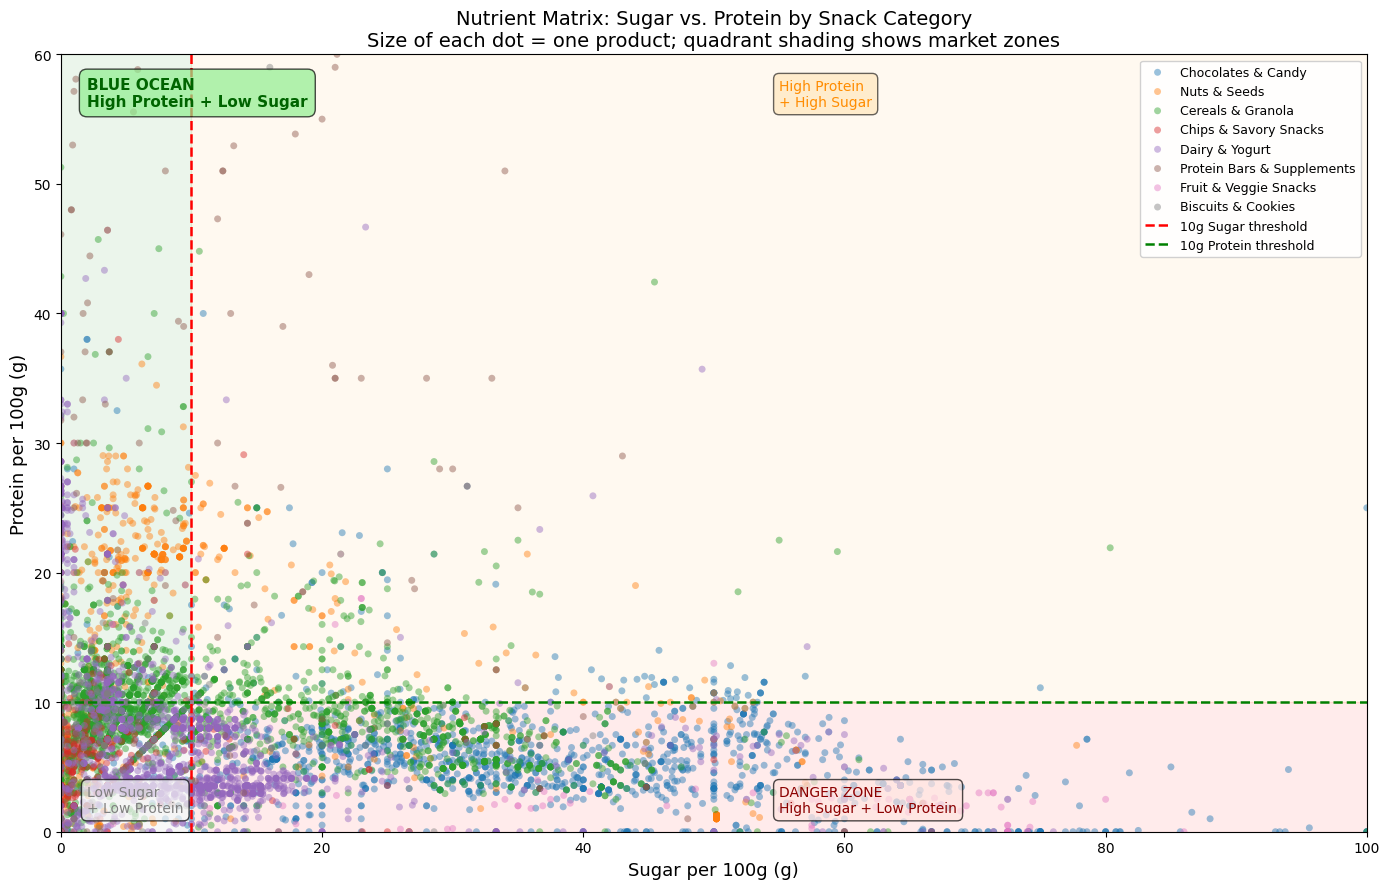

In [8]:
plot_df = df_clean_viz[df_clean_viz['primary_category'] != 'Other'].copy()
plot_df = plot_df.sample(min(8000, len(plot_df)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 9))

# Shade the four quadrants first (drawn behind the dots)
ax.axvspan(0, 10, ymin=10/60, ymax=1, alpha=0.08, color='green')   # Blue Ocean: low sugar, high protein
ax.axvspan(10, 100, ymin=10/60, ymax=1, alpha=0.06, color='orange') # High sugar, high protein
ax.axvspan(0, 10, ymin=0, ymax=10/60, alpha=0.06, color='grey')     # Low sugar, low protein
ax.axvspan(10, 100, ymin=0, ymax=10/60, alpha=0.08, color='red')    # Danger zone: high sugar, low protein

# Plot each category
palette = sns.color_palette("tab10", len(plot_df['primary_category'].unique()))
for i, cat in enumerate(plot_df['primary_category'].unique()):
    subset = plot_df[plot_df['primary_category'] == cat]
    ax.scatter(subset['sugars_100g'], subset['proteins_100g'],
               label=cat, alpha=0.45, s=25, color=palette[i], edgecolors='none')

# Quadrant divider lines
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.8, label='10g Sugar threshold')
ax.axhline(y=10, color='green', linestyle='--', linewidth=1.8, label='10g Protein threshold')

# Quadrant labels — large, clear, positioned in corners
ax.text(2, 56, 'BLUE OCEAN\nHigh Protein + Low Sugar',
        fontsize=11, color='darkgreen', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))

ax.text(55, 56, 'High Protein\n+ High Sugar',
        fontsize=10, color='darkorange',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='moccasin', alpha=0.6))

ax.text(55, 1.5, 'DANGER ZONE\nHigh Sugar + Low Protein',
        fontsize=10, color='darkred',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', alpha=0.7))

ax.text(2, 1.5, 'Low Sugar\n+ Low Protein',
        fontsize=10, color='grey',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='whitesmoke', alpha=0.7))

ax.set_xlabel('Sugar per 100g (g)', fontsize=13)
ax.set_ylabel('Protein per 100g (g)', fontsize=13)
ax.set_title('Nutrient Matrix: Sugar vs. Protein by Snack Category\n'
             'Size of each dot = one product; quadrant shading shows market zones',
             fontsize=14)
ax.set_xlim(0, 100)
ax.set_ylim(0, 60)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('nutrient_matrix.png', dpi=150)
plt.show()

In [9]:
# Step 4: Per-category averages table
category_summary = df_clean_viz[df_clean_viz['primary_category'] != 'Other'].groupby('primary_category').agg(
    avg_sugar=('sugars_100g', 'mean'),
    avg_protein=('proteins_100g', 'mean'),
    avg_fat=('fat_100g', 'mean'),
    product_count=('product_name', 'count')
).round(2).reset_index()

category_summary = category_summary.sort_values('avg_protein', ascending=False)
print(category_summary)

# Export it immediately
category_summary.to_csv("category_summary.csv", index=False)
print("category_summary exported.")

             primary_category  avg_sugar  avg_protein  avg_fat  product_count
7  Protein Bars & Supplements       7.07        43.43     6.32            381
6                Nuts & Seeds      10.41        13.25    27.08           1279
1           Cereals & Granola      10.64         9.16     5.67           5033
0          Biscuits & Cookies       5.49         8.80    15.47            192
4              Dairy & Yogurt       9.02         7.66     7.78           3452
2       Chips & Savory Snacks       4.14         6.54    23.03            694
3          Chocolates & Candy      33.38         5.93    18.04           2697
5       Fruit & Veggie Snacks      48.30         3.82     4.23            132
category_summary exported.


# The Recommendation

In [10]:
# Find the "Blue Ocean" products: Low Sugar (<10g) AND High Protein (>10g)
blue_ocean = df_clean_viz[
    (df_clean['sugars_100g'] < 10) &
    (df_clean['proteins_100g'] > 10) &
    (df_clean['primary_category'] != 'Other')
]

print("Total Blue Ocean products found:", len(blue_ocean))
print("\nBlue Ocean products by category:")
print(blue_ocean['primary_category'].value_counts())

# Get the median protein and sugar values for the recommendation sentence
median_protein = blue_ocean['proteins_100g'].median()
median_sugar = blue_ocean['sugars_100g'].median()
top_category = blue_ocean['primary_category'].value_counts().idxmax()

print(f"\n --- RECOMMENDATION SENTENCE ---")
print(f"Based on the data, the biggest market opportunity is in [{top_category}],")
print(f"specifically targeting products with [{median_protein:.0f}]g of protein")
print(f"and less than [{median_sugar:.0f}]g of sugar per 100g.")

Total Blue Ocean products found: 2728

Blue Ocean products by category:
primary_category
Cereals & Granola             1144
Dairy & Yogurt                 611
Nuts & Seeds                   581
Protein Bars & Supplements     209
Chocolates & Candy              95
Chips & Savory Snacks           44
Biscuits & Cookies              41
Fruit & Veggie Snacks            3
Name: count, dtype: int64

 --- RECOMMENDATION SENTENCE ---
Based on the data, the biggest market opportunity is in [Cereals & Granola],
specifically targeting products with [14]g of protein
and less than [3]g of sugar per 100g.


/tmp/ipykernel_44816/2181528284.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  blue_ocean = df_clean_viz[


# BONUS

In [11]:
# Step 1: Filter to high-protein products (top 25% of protein content)
protein_threshold = df_clean['proteins_100g'].quantile(0.75)
high_protein = df_clean[
    (df_clean['proteins_100g'] >= protein_threshold) &
    (df_clean['ingredients_text'].notna())
].copy()

print(f"High protein threshold: {protein_threshold:.1f}g — {len(high_protein)} products")

# Step 2: Define known protein source keywords to search for
protein_keywords = [
    'whey', 'soy', 'pea protein', 'peanut', 'almond', 'casein',
    'egg', 'milk protein', 'hemp', 'chickpea', 'rice protein', 'lentil'
]

# Step 3: Count how often each keyword appears across all ingredient texts
ingredient_blob = ' '.join(high_protein['ingredients_text'].str.lower().tolist())

keyword_counts = {}
for kw in protein_keywords:
    count = ingredient_blob.count(kw)
    if count > 0:
        keyword_counts[kw] = count

# Step 4: Sort and display top 3
sorted_keywords = sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True)
print("\nTop protein sources in high-protein products:")
for rank, (kw, count) in enumerate(sorted_keywords[:3], 1):
    print(f"  #{rank}: '{kw}' — appears in ingredient lists {count} times")

High protein threshold: 10.8g — 4798 products

Top protein sources in high-protein products:
  #1: 'soy' — appears in ingredient lists 2154 times
  #2: 'peanut' — appears in ingredient lists 748 times
  #3: 'whey' — appears in ingredient lists 667 times


# Candidate's choice 

# NOTE on Fruit & Veggie Snacks scoring low:
### This category is dominated by dried fruits (raisins, dates, mango strips)
### which are naturally very high in sugar (~50g/100g), driving the score negative.
### This does NOT mean fresh fruit is unhealthy — it reflects the specific
### products captured in this dataset under these tags.

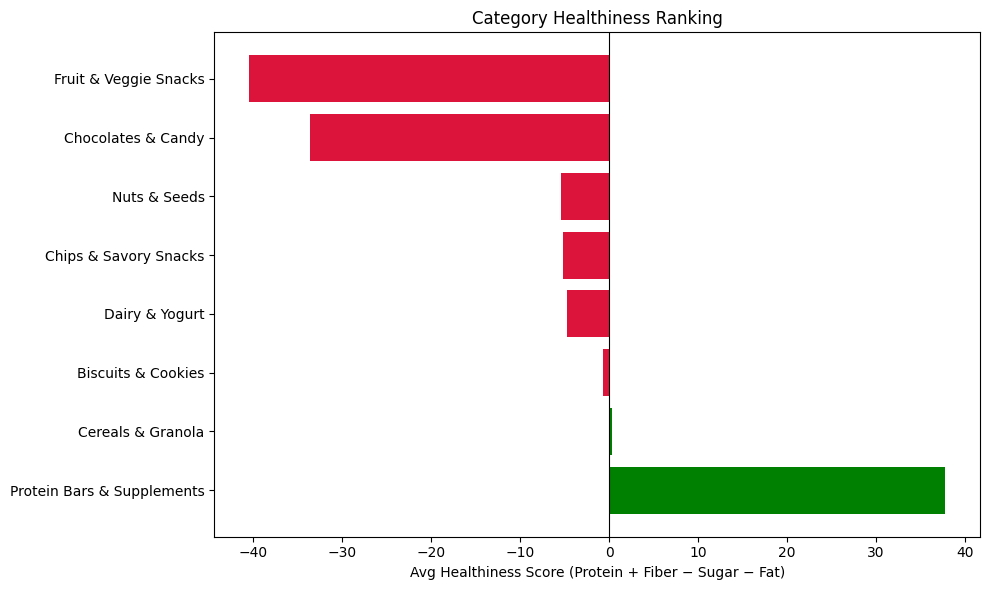

In [12]:
# Create a composite "Healthiness Score" per category
# Score = Protein + Fiber - Sugar - Fat (per 100g)
# This single number lets you rank categories from worst to best nutritionally

df_scored = df_clean_viz[df_clean_viz['primary_category'] != 'Other'].copy()
df_scored['fat_100g'] = df_scored['fat_100g'].fillna(df_scored['fat_100g'].median())
df_scored['fiber_100g'] = df_scored['fiber_100g'].fillna(0)

df_scored['health_score'] = (
    df_scored['proteins_100g'] +
    df_scored['fiber_100g'] -
    df_scored['sugars_100g'] -
    (df_scored['fat_100g'] * 0.5)   # fat is penalized at half weight
)

category_health = df_scored.groupby('primary_category')['health_score'].mean().reset_index()
category_health = category_health.sort_values('health_score', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'crimson' for x in category_health['health_score']]
plt.barh(category_health['primary_category'], category_health['health_score'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Avg Healthiness Score (Protein + Fiber − Sugar − Fat)')
plt.title("Category Healthiness Ranking")
plt.tight_layout()
plt.savefig('health_score_ranking.png', dpi=150)
plt.show()

## Exporting the datasets to csv

In [13]:
# Export 1: The main clean dataset (for most charts)
df_clean.to_csv("main_clean.csv", index=False)

# Export 2: Category summary table (avg sugar, protein, fat per category)
category_summary.to_csv("category_summary.csv", index=False)

# Export 3: Blue Ocean products only
blue_ocean.to_csv("blue_ocean_products.csv", index=False)

# Export 4: Healthiness score per category
category_health.to_csv("healthiness_score.csv", index=False)

print("All files exported successfully.")

All files exported successfully.
